In [1]:
import sys
print(f"Python: {sys.version}")
print(f"Executable: {sys.executable}")

# Test DeepMol import
try:
    import deepmol
    print(" DeepMol imported successfully!")
    
    # Test if you can access compound_featurization
    from deepmol import compound_featurization
    print(" DeepMol compound_featurization module found")
    
except ImportError as e:
    print(f" DeepMol import failed: {e}")

# Test ChemBERTa import
try:
    from deepmol.compound_featurization import HuggingFaceFeaturizer
    print(" HuggingFaceFeaturizer imported successfully")
    
    # Test initialization
    featurizer = HuggingFaceFeaturizer()
    print(" HuggingFaceFeaturizer initialized successfully")
    
except ImportError as e:
    print(f" HuggingFaceFeaturizer import failed: {e}")
except Exception as e:
    print(f" HuggingFaceFeaturizer initialization failed: {e}")

Python: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
Executable: /home/jcheixo/miniforge3/envs/deepmol/bin/python
 DeepMol imported successfully!


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
2026-04-24 10:43:22.944109: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 10:43:22.944183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 10:43:22.946380: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-24 10:43:22.959260: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild Tens

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


 DeepMol compound_featurization module found
 HuggingFaceFeaturizer imported successfully


Some weights of RobertaModel were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['embeddings.word_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 HuggingFaceFeaturizer initialized successfully


In [2]:
import sys
print("Python executable:", sys.executable)
print("\nPython path:")
for path in sys.path:
    print(path)

Python executable: /home/jcheixo/miniforge3/envs/deepmol/bin/python

Python path:
/home/jcheixo/miniforge3/envs/deepmol/lib/python39.zip
/home/jcheixo/miniforge3/envs/deepmol/lib/python3.9
/home/jcheixo/miniforge3/envs/deepmol/lib/python3.9/lib-dynload

/home/jcheixo/.local/lib/python3.9/site-packages
/home/jcheixo/miniforge3/envs/deepmol/lib/python3.9/site-packages
/home/jcheixo/DeepMol/src
/home/jcheixo/miniforge3/envs/deepmol/lib/python3.9/site-packages/setuptools/_vendor
/tmp/tmpq9dykx8a


In [3]:
# Quick functionality test
from rdkit import Chem
from deepmol.compound_featurization import HuggingFaceFeaturizer

# Test with a simple molecule
test_smiles = "CCO"  # Ethanol
mol = Chem.MolFromSmiles(test_smiles)

try:
    # Initialize your featurizer
    featurizer = HuggingFaceFeaturizer()
    print(" HuggingFaceFeaturizer initialized")
    
    # Test featurization
    embedding = featurizer._featurize(mol)
    print(f" Featurization successful! Embedding shape: {embedding.shape}")
    print(f" Embedding dimension: {len(embedding)}")
    print(f" First 5 values: {embedding[:5]}")
    
except Exception as e:
    print(f" Error during featurization: {e}")

 HuggingFaceFeaturizer initialized
 Featurization successful! Embedding shape: (768,)
 Embedding dimension: 768
 First 5 values: [ 0.5377539   1.1050246   0.06445608 -1.2604325   0.27304402]


In [17]:
# Benchmarking All ChemBERTa Model Variants with DeepMol HPO
# Using HyperparameterOptimizerValidation as per DeepMol documentation

import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# DeepMol imports
from deepmol.compound_featurization import HuggingFaceFeaturizer
from deepmol.loaders import CSVLoader
from deepmol.splitters import RandomSplitter
from deepmol.metrics import Metric
from deepmol.parameter_optimization import HyperparameterOptimizerValidation

# Model imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, average_precision_score
import torch


In [5]:
# Data Loading for DeepMol Benchmarking
import os
import pandas as pd
import requests
import zipfile
from deepmol.loaders import CSVLoader
import numpy as np

def download_dataset(dataset_url, local_path):
    """Download dataset from URL to local path"""
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    
    # Download if file doesn't exist
    if not os.path.exists(local_path):
        print(f" Downloading dataset from {dataset_url}...")
        
        if dataset_url.endswith('.zip') or dataset_url.endswith('.gz'):
            # Handle compressed files
            compressed_path = local_path + '.gz' if dataset_url.endswith('.gz') else local_path.replace('.csv', '.zip')
            response = requests.get(dataset_url)
            with open(compressed_path, 'wb') as f:
                f.write(response.content)
            
            if dataset_url.endswith('.zip'):
                # Extract zip
                with zipfile.ZipFile(compressed_path, 'r') as zip_ref:
                    zip_ref.extractall(os.path.dirname(local_path))
                os.remove(compressed_path)
            else:  # gz file
                import gzip
                import shutil
                with gzip.open(compressed_path, 'rb') as f_in:
                    with open(local_path, 'wb') as f_out:
                        shutil.copyfileobj(f_in, f_out)
                os.remove(compressed_path)
        else:
            # Direct CSV download
            response = requests.get(dataset_url)
            with open(local_path, 'wb') as f:
                f.write(response.content)
        
        print(f" Dataset saved to {local_path}")
    else:
        print(f" Dataset already exists at {local_path}")

def load_benchmark_data():
    """Load dataset using DeepMol's CSVLoader with proper format"""
    config = HuggingFaceFeaturizerBenchmarkConfig()
    
    # Download dataset if using URL
    if hasattr(config, 'DATASET_URL') and config.DATASET_URL:
        download_dataset(config.DATASET_URL, config.DATASET_PATH)
    
    print(f"   Loading dataset using DeepMol CSVLoader...")
    print(f"   Path: {config.DATASET_PATH}")
    print(f"   SMILES column: {config.SMILES_COLUMN}")
    print(f"   Target column: {config.TARGET_COLUMN}")
    
    # Use DeepMol's CSVLoader exactly as in your class definition
    loader = CSVLoader(
        dataset_path=config.DATASET_PATH,
        smiles_field=config.SMILES_COLUMN,
        labels_fields=[config.TARGET_COLUMN],
        id_field=None,  # Optional: specify if you have an ID column
        features_fields=None,  # Optional: specify if you have pre-computed features
        mode='auto'  # Let DeepMol infer classification/regression
    )
    
    dataset = loader.create_dataset()
    
    print(f" Successfully loaded dataset with {len(dataset)} molecules")
    print(f" Dataset type: {type(dataset)}")
    print(f" Features shape: {dataset.X.shape if dataset.X is not None else 'No features'}")
    print(f" Labels shape: {dataset.y.shape if dataset.y is not None else 'No labels'}")
    print(f" Class distribution: {np.bincount(dataset.y) if dataset.y is not None else 'No labels'}")
    
    return dataset

# Configuration with multiple dataset options
class HuggingFaceFeaturizerBenchmarkConfig:
    """Configuration for benchmarking different ChemBERTa models"""
    
    # dataset option:
    
    # Option 1: BACE Dataset (Classification)
    # DATASET_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv"
    # DATASET_PATH = "./data/bace.csv"
    # SMILES_COLUMN = "mol"
    # TARGET_COLUMN = "Class"
    
    # Option 2: HIV Dataset (Classification)
    DATASET_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv"
    DATASET_PATH = "./data/hiv.csv"
    SMILES_COLUMN = "smiles"
    TARGET_COLUMN = "HIV_active"
    
    # Option 3: BBBP Dataset (Classification)
    # DATASET_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
    # DATASET_PATH = "./data/bbbp.csv"
    # SMILES_COLUMN = "smiles"
    # TARGET_COLUMN = "p_np"
    
    # Option 4: Use local file (comment out DATASET_URL)
    # DATASET_URL = None
    # DATASET_PATH = "/path/to/your/dataset.csv"
    # SMILES_COLUMN = "smiles"
    # TARGET_COLUMN = "activity"
    
    # ChemBERTa models to benchmark
    CHEM_MODELS = {
        "ChemBERTa-zinc-base": {
            "model_name": "seyonec/ChemBERTa-zinc-base-v1",
            "description": "Base model trained on ZINC dataset (768 dim)"
        },
        "ChemBERTa-pubchem": {
            "model_name": "seyonec/PubChem10M_SMILES_BPE_396_250", 
            "description": "Trained on PubChem10M dataset (256 dim)"
        },
        "ChemBERTa-77M-MLM": {
            "model_name": "DeepChem/ChemBERTa-77M-MLM",
            "description": "77M parameters, Masked Language Modeling (768 dim)"
        },
        "ChemBERTa-77M-MTR": {
            "model_name": "DeepChem/ChemBERTa-77M-MTR",
            "description": "77M parameters, Multi-Task Regression (768 dim)"
        }
    }
    
    # Experiment settings
    TEST_SIZE = 0.2
    VALID_SIZE = 0.2
    RANDOM_STATE = 42
    N_ITER_SEARCH = 15
    BATCH_SIZE = 16
    
    # HPO configurations
    HPO_CONFIGS = {
        "RandomForest": {
            "model": RandomForestClassifier,
            "param_grid": {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'class_weight': ['balanced', None]
            }
        },
        "SVM": {
            "model": SVC,
            "param_grid": {
                'C': [0.1, 1, 10, 100],
                'kernel': ['linear', 'rbf', 'poly'],
                'gamma': ['scale', 'auto'],
                'class_weight': ['balanced', None],
                'probability': [True]
            }
        },
        "LogisticRegression": {
            "model": LogisticRegression,
            "param_grid": {
                'C': [0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2'],
                'solver': ['liblinear', 'saga'],
                'class_weight': ['balanced', None],
                'max_iter': [1000]
            }
        }
    }

In [6]:
# Test the data loading
print(" Testing data loading...")
try:
    dataset = load_benchmark_data()
    print(" Data loading successful!")
    
    # Display dataset info
    print(f"\n Dataset Information:")
    print(f"   Number of samples: {len(dataset)}")
    print(f"   SMILES examples: {dataset.smiles[:3] if hasattr(dataset, 'smiles') else 'N/A'}")
    print(f"   Labels: {dataset.y[:10] if dataset.y is not None else 'N/A'}")
    print(f"   Label names: {dataset.label_names}")
    print(f"   Mode: {dataset.mode}")
    
except Exception as e:
    print(f" Data loading failed: {e}")
    import traceback
    traceback.print_exc()

 Testing data loading...
 Dataset saved to ./data/hiv.csv
   Loading dataset using DeepMol CSVLoader...
   Path: ./data/hiv.csv
   SMILES column: smiles
   Target column: HIV_active
2026-04-24 10:44:51,017 — INFO — Assuming classification since there are less than 10 unique y values. If otherwise, explicitly set the mode to 'regression'!
 Successfully loaded dataset with 41127 molecules
 Dataset type: <class 'deepmol.datasets.datasets.SmilesDataset'>
 Features shape: No features
 Labels shape: (41127,)
 Class distribution: [39684  1443]
 Data loading successful!

 Dataset Information:
   Number of samples: 41127
   SMILES examples: ['CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2'
 'C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3)CC(c3ccccc3)=[O+]2)[O+]=C(c2ccccc2)C1'
 'CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21']
   Labels: [0 0 0 0 0 0 0 0 0 0]
   Label names: ['HIV_active']
   Mode: classification


In [7]:
#inspect the raw CSV first:
def inspect_dataset():
    """Inspect the dataset before loading with DeepMol"""
    config = HuggingFaceFeaturizerBenchmarkConfig()
    
    if hasattr(config, 'DATASET_URL') and config.DATASET_URL:
        download_dataset(config.DATASET_URL, config.DATASET_PATH)
    
    # Read with pandas to inspect
    df = pd.read_csv(config.DATASET_PATH)
    print(f" Dataset shape: {df.shape}")
    print(f" Columns: {df.columns.tolist()}")
    print(f" First few rows:")
    print(df.head())
    
    # Check for the specific columns we need
    if config.SMILES_COLUMN not in df.columns:
        print(f" ERROR: SMILES column '{config.SMILES_COLUMN}' not found in dataset")
        print(f"   Available columns: {df.columns.tolist()}")
        return None
        
    if config.TARGET_COLUMN not in df.columns:
        print(f" ERROR: Target column '{config.TARGET_COLUMN}' not found in dataset")
        print(f"   Available columns: {df.columns.tolist()}")
        return None
    
    print(f" Required columns found: '{config.SMILES_COLUMN}' and '{config.TARGET_COLUMN}'")
    print(f" Target value distribution:")
    print(df[config.TARGET_COLUMN].value_counts())
    
    return df

# inspect the dataset first
inspect_dataset()

 Dataset already exists at ./data/hiv.csv
 Dataset shape: (41127, 3)
 Columns: ['smiles', 'activity', 'HIV_active']
 First few rows:
                                              smiles activity  HIV_active
0  CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...       CI           0
1  C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...       CI           0
2                   CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21       CI           0
3    Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1       CI           0
4                             O=S(=O)(O)CCS(=O)(=O)O       CI           0
 Required columns found: 'smiles' and 'HIV_active'
 Target value distribution:
HIV_active
0    39684
1     1443
Name: count, dtype: int64


,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0
...,...,...,...
41122,CCC1CCC2c3c([nH]c4ccc(C)cc34)C3C(=O)N(N(C)C)C(...,CI,0
41123,Cc1ccc2[nH]c3c(c2c1)C1CCC(C(C)(C)C)CC1C1C(=O)N...,CI,0
41124,Cc1ccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)C...,CI,0
41125,Cc1cccc(N2C(=O)C3c4[nH]c5ccccc5c4C4CCC(C(C)(C)...,CI,0


In [8]:
# Progress Bar Manager
class ProgressBarManager:
    """Manage progress bars for different stages of benchmarking"""
    
    def __init__(self):
        self.bars = {}
        
    def create_bar(self, key, total, desc):
        """Create a new progress bar"""
        self.bars[key] = tqdm(total=total, desc=desc, ncols=100, leave=False)
        return self.bars[key]
    
    def update_bar(self, key, increment=1):
        """Update a specific progress bar"""
        if key in self.bars:
            self.bars[key].update(increment)
    
    def close_bar(self, key):
        """Close a specific progress bar"""
        if key in self.bars:
            self.bars[key].close()
            del self.bars[key]
    
    def close_all(self):
        """Close all progress bars"""
        for key in list(self.bars.keys()):
            self.close_bar(key)

# Global progress manager
progress_manager = ProgressBarManager()

In [23]:
# Benchmarking Code that Uses the Returned Dataset
class CorrectHuggingFaceFeaturizerBenchmark:
    """ benchmark that uses the returned dataset from featurize()"""
    
    def __init__(self, model_config, dataset, config):
        self.model_name = model_config["model_name"]
        self.description = model_config["description"]
        self.original_dataset = dataset
        self.config = config
        self.results = {}
        self.best_models = {}
        self.best_hyperparams = {}
        self.all_results = {}
        self.featurized_dataset = None
        self.featurization_time = None
        
    def featurize_data(self):
        """Featurize data and use the returned dataset"""
        print(f"\n Featurizing with {self.model_name}...")
        
        try:
            start_time = time.time()
            
            featurizer = HuggingFaceFeaturizer(
                model_name=self.model_name,
                device="cuda" if torch.cuda.is_available() else "cpu",
                batch_size=self.config.BATCH_SIZE,
                pooling="mean"
            )
            
            # Featurize with progress - CAPTURE THE RETURNED DATASET
            pbar = progress_manager.create_bar(
                f"featurize_{self.model_name}", 1, f"Featurizing {self.model_name}"
            )
            
            # The featurize method RETURNS a new dataset with features
            self.featurized_dataset = featurizer.featurize(self.original_dataset)
            
            progress_manager.update_bar(f"featurize_{self.model_name}", 1)
            progress_manager.close_bar(f"featurize_{self.model_name}")
            
            self.featurization_time = time.time() - start_time
            
            # Verify features are present
            if self.featurized_dataset.X is not None:
                print(f" {self.model_name}: {self.featurized_dataset.X.shape[1]}D embeddings "
                      f"({self.featurization_time:.2f}s)")
                return True
            else:
                print(f" {self.model_name}: No features in returned dataset")
                return False
            
        except Exception as e:
            print(f" Failed to featurize with {self.model_name}: {str(e)}")
            import traceback
            traceback.print_exc()
            return False
    
    def run_hpo_for_algorithm(self, algorithm_name):
        """Run HPO for a specific algorithm"""
        print(f"    Running HPO for {algorithm_name}...")
        
        config = HuggingFaceFeaturizerBenchmarkConfig()

        # Ensure we have a featurized dataset
        if self.featurized_dataset is None:
            featurization_success = self.featurize_data()
            if not featurization_success:
                print(f"     No featurized dataset available for {algorithm_name}")
                return None
        
        algorithm_config = self.config.HPO_CONFIGS[algorithm_name]
        
        # Split data into train, validation, and test
        splitter = RandomSplitter()
        
        # First split: separate test set
        train_valid_dataset, test_dataset = splitter.train_test_split(
            self.featurized_dataset, 
            test_size=self.config.TEST_SIZE,
            random_state=self.config.RANDOM_STATE
        )
        
        # Second split: separate train and validation for HPO
        train_dataset, valid_dataset = splitter.train_test_split(
            train_valid_dataset,
            test_size=self.config.VALID_SIZE,
            random_state=self.config.RANDOM_STATE
        )
        
        #for imbalanced datasets, apply SMOTE to the training set only
        train_dataset = apply_smote_to_deepmol_dataset(train_dataset)

        print(f"      Data splits - Train: {len(train_dataset)}, "
              f"Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")
        

        
        # Define metrics / added PR-AUC metric
        metrics = [
            Metric(roc_auc_score, name="roc_auc"),
            Metric(accuracy_score, name="accuracy"),
            Metric(f1_score, name="f1"),
            Metric(precision_score, name="precision"),
            Metric(recall_score, name="recall"),
            Metric(average_precision_score, name="pr_auc"),
        ]
        
        try:
            # Create progress bar for HPO
            hpo_bar = progress_manager.create_bar(
                f"hpo_{self.model_name}_{algorithm_name}", 
                self.config.N_ITER_SEARCH,
                f"HPO {algorithm_name}"
            )
            
            # Run HPO with Validation set
            optimizer = HyperparameterOptimizerValidation(
                algorithm_config["model"],
                metric=Metric(roc_auc_score),
                maximize_metric=True,
                n_iter_search=self.config.N_ITER_SEARCH,
                params_dict=algorithm_config["param_grid"],
                model_type="sklearn"
            )
            
            # Fit with train and validation sets
            best_model, best_hyperparams, all_results = optimizer.fit(
                train_dataset=train_dataset, 
                valid_dataset=valid_dataset
            )
            
            progress_manager.close_bar(f"hpo_{self.model_name}_{algorithm_name}")
            
            # Evaluate best model on test set
            test_results = best_model.evaluate(test_dataset, metrics)
            
            # Store results
            self.results[algorithm_name] = test_results
            self.best_models[algorithm_name] = best_model
            self.best_hyperparams[algorithm_name] = best_hyperparams
            self.all_results[algorithm_name] = all_results
            
            print(f"     {algorithm_name}: ROC-AUC = {test_results['roc_auc']:.4f}, "
                  f"F1 = {test_results['f1']:.4f}")
            print(f"     Best hyperparams: {best_hyperparams}")
            
            return test_results
            
        except Exception as e:
            print(f"     {algorithm_name} HPO failed: {str(e)}")
            progress_manager.close_bar(f"hpo_{self.model_name}_{algorithm_name}")
            return None
    
    def benchmark_all_algorithms(self):
        """Run benchmarking for all algorithms"""
        # Ensure we have featurized data
        if self.featurized_dataset is None:
            featurization_success = self.featurize_data()
            if not featurization_success:
                print(f" Cannot benchmark {self.model_name} - featurization failed")
                return None
        
        print(f"\n BENCHMARKING: {self.model_name}")
        print(f"   Description: {self.description}")
        print(f"   Feature dimension: {self.featurized_dataset.X.shape[1]}")
        print("-" * 60)
        
        # Create progress bar for algorithms
        algo_bar = progress_manager.create_bar(
            f"algorithms_{self.model_name}",
            len(self.config.HPO_CONFIGS),
            f"Algorithms for {self.model_name}"
        )
        
        successful_algorithms = 0
        for algorithm_name in self.config.HPO_CONFIGS.keys():
            result = self.run_hpo_for_algorithm(algorithm_name)
            if result is not None:
                successful_algorithms += 1
            progress_manager.update_bar(f"algorithms_{self.model_name}", 1)
        
        progress_manager.close_bar(f"algorithms_{self.model_name}")
        
        if successful_algorithms > 0:
            print(f" Completed {self.model_name}: {successful_algorithms}/{len(self.config.HPO_CONFIGS)} algorithms successful")
            return self.results, self.best_models, self.best_hyperparams
        else:
            print(f" All algorithms failed for {self.model_name}")
            return None

In [10]:
#  Results Analyzer that handles multiple models 
class HuggingFaceFeaturizerResultsAnalyzer:
    """ analyzer that handles results from multiple models"""
    
    def __init__(self, all_results):
        self.all_results = all_results
        print(f" Analyzer initialized with {len(all_results)} models")
        for model_key in all_results.keys():
            print(f"   - {model_key}")
    
    def create_comprehensive_dataframe(self):
        """Create detailed results DataFrame - for multiple models"""
        rows = []
        
        print(f" Creating DataFrame from {len(self.all_results)} models...")
        
        for model_key, model_data in self.all_results.items():
            print(f"   Processing {model_key}...")
            
            model_info = model_data['model_info']
            results = model_data['results']
            feature_dim = model_data['feature_dim']
            best_hyperparams = model_data.get('best_hyperparams', {})
            featurization_time = model_data.get('featurization_time', 0)
            
            print(f"      Found {len(results)} algorithms: {list(results.keys())}")
            
            for algorithm, metrics in results.items():
                # Debug: print the metrics structure
                print(f"      Algorithm {algorithm} metrics: {list(metrics.keys()) if isinstance(metrics, dict) else type(metrics)}")
                
                row_data = {
                    'ChemBERTa_Model': model_key,
                    'Model_Name': model_info['model_name'],
                    'Description': model_info['description'],
                    'Feature_Dimension': feature_dim,
                    'Algorithm': algorithm,
                    'ROC_AUC': metrics.get('roc_auc', 0) if isinstance(metrics, dict) else 0,
                    'Accuracy': metrics.get('accuracy', 0) if isinstance(metrics, dict) else 0,
                    'F1_Score': metrics.get('f1', 0) if isinstance(metrics, dict) else 0,
                    'Precision': metrics.get('precision', 0) if isinstance(metrics, dict) else 0,
                    'Recall': metrics.get('recall', 0) if isinstance(metrics, dict) else 0,
                    'Best_Hyperparams': str(best_hyperparams.get(algorithm, {})),
                    'Featurization_Time_Seconds': featurization_time
                }
                
                # Debug: print the first row to check values
                if len(rows) == 0:
                    print(f"      Sample row data: {row_data}")
                
                rows.append(row_data)
        
        df = pd.DataFrame(rows)
        print(f" Created DataFrame with {len(df)} rows from {len(self.all_results)} models")
        return df
    
    def plot_model_comparison(self):
        """Create comprehensive comparison plots - for multiple models"""
        df = self.create_comprehensive_dataframe()
        
        if df.empty:
            print(" No data to plot")
            return df
        
        print(f" Plotting data for {len(df['ChemBERTa_Model'].unique())} models and {len(df['Algorithm'].unique())} algorithms")
        
        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('ROC-AUC by ChemBERTa Model and Algorithm', 
                          'Average Performance by ChemBERTa Model',
                          'Performance Heatmap Across All Combinations',
                          'Feature Dimension vs Performance'),
            specs=[[{"type": "bar"}, {"type": "bar"}],
                   [{"type": "heatmap"}, {"type": "scatter"}]]
        )
        
        # 1. ROC-AUC by Model and Algorithm
        algorithms = df['Algorithm'].unique()
        print(f"   Algorithms found: {algorithms}")
        
        for algorithm in algorithms:
            algorithm_data = df[df['Algorithm'] == algorithm]
            if not algorithm_data.empty:
                fig.add_trace(
                    go.Bar(name=algorithm, x=algorithm_data['ChemBERTa_Model'], 
                          y=algorithm_data['ROC_AUC']),
                    row=1, col=1
                )
        
        # 2. Average Performance by ChemBERTa Model
        avg_performance = df.groupby('ChemBERTa_Model')[['ROC_AUC', 'Accuracy', 'F1_Score']].mean()
        print(f"   Average performance: {avg_performance}")
        
        for metric in ['ROC_AUC', 'Accuracy', 'F1_Score']:
            if metric in avg_performance.columns:
                fig.add_trace(
                    go.Bar(name=metric, x=avg_performance.index, y=avg_performance[metric]),
                    row=1, col=2
                )
        
        # 3. Performance Heatmap
        try:
            heatmap_data = df.pivot(index='ChemBERTa_Model', columns='Algorithm', values='ROC_AUC')
            fig.add_trace(
                go.Heatmap(z=heatmap_data.values, 
                          x=heatmap_data.columns, 
                          y=heatmap_data.index,
                          colorscale='Viridis',
                          hoverinfo='z',
                          colorbar=dict(title="ROC-AUC")),
                row=2, col=1
            )
        except Exception as e:
            print(f"  Could not create heatmap: {e}")
        
        # 4. Feature Dimension vs Performance
        fig.add_trace(
            go.Scatter(x=df['Feature_Dimension'], 
                      y=df['ROC_AUC'],
                      mode='markers',
                      marker=dict(size=10, color=df['ROC_AUC'], colorscale='Viridis'),
                      text=df['ChemBERTa_Model'] + ' + ' + df['Algorithm'],
                      hoverinfo='text+x+y'),
            row=2, col=2
        )
        
        fig.update_layout(height=800, showlegend=True, 
                         title_text="Comprehensive ChemBERTa Model Benchmarking")
        fig.show()
        
        return df
    
    def print_detailed_analysis(self, df):
        """Print detailed analysis of results - FIXED for multiple models"""
        if df.empty:
            print(" No results to analyze")
            return
        
        print("\n" + "="*100)
        print("COMPREHENSIVE CHEMBERTA BENCHMARKING RESULTS")
        print("="*100)
        
        # Check if we have multiple models
        unique_models = df['ChemBERTa_Model'].unique()
        print(f" Analyzing {len(unique_models)} models: {list(unique_models)}")
        
        # Best overall combination
        if not df.empty and 'ROC_AUC' in df.columns:
            best_overall = df.loc[df['ROC_AUC'].idxmax()]
            print(f"\n BEST OVERALL COMBINATION:")
            print(f"   ChemBERTa Model: {best_overall['ChemBERTa_Model']}")
            print(f"   Algorithm: {best_overall['Algorithm']}")
            print(f"   ROC-AUC: {best_overall['ROC_AUC']:.4f}")
            print(f"   F1-Score: {best_overall['F1_Score']:.4f}")
            print(f"   Feature Dimension: {best_overall['Feature_Dimension']}")
            print(f"   Best Hyperparameters: {best_overall['Best_Hyperparams']}")
        else:
            print(" No valid results for best overall combination")
        
        # Best by ChemBERTa model
        if len(unique_models) > 1:
            print(f"\n BEST ALGORITHM FOR EACH CHEMBERTA MODEL:")
            best_by_chem_model = df.loc[df.groupby('ChemBERTa_Model')['ROC_AUC'].idxmax()]
            for _, row in best_by_chem_model.iterrows():
                print(f"   {row['ChemBERTa_Model']:25} → {row['Algorithm']:20} ROC-AUC: {row['ROC_AUC']:.4f}")
        else:
            print(f"\n Only one model found: {unique_models[0]}")
        
        # Best by algorithm
        unique_algorithms = df['Algorithm'].unique()
        if len(unique_algorithms) > 1:
            print(f"\n BEST CHEMBERTA MODEL FOR EACH ALGORITHM:")
            best_by_algorithm = df.loc[df.groupby('Algorithm')['ROC_AUC'].idxmax()]
            for _, row in best_by_algorithm.iterrows():
                print(f"   {row['Algorithm']:20} → {row['ChemBERTa_Model']:25} ROC-AUC: {row['ROC_AUC']:.4f}")
        
        # Summary statistics
        print(f"\n SUMMARY STATISTICS BY CHEMBERTA MODEL:")
        if len(unique_models) > 1:
            summary = df.groupby('ChemBERTa_Model').agg({
                'ROC_AUC': ['mean', 'std', 'max', 'min'],
                'Accuracy': 'mean',
                'F1_Score': 'mean',
                'Feature_Dimension': 'first',
                'Featurization_Time_Seconds': 'first'
            }).round(4)
            print(summary)
            
            # Performance vs Feature Dimension correlation
            if len(df) > 1:
                correlation = df['Feature_Dimension'].corr(df['ROC_AUC'])
                print(f"\n Correlation between Feature Dimension and ROC-AUC: {correlation:.4f}")
            else:
                print(f"\n Cannot compute correlation with only one data point")
        else:
            print("   Only one model available - cannot compute summary statistics")

In [31]:
# function to check what's in the results
def debug_results_structure(all_results):
    """Debug the structure of the results to see what's available"""
   
    
    if not all_results:
        print(" No results to debug")
        return
    
    print(f"Total models in results: {len(all_results)}")
    print(f"Model keys: {list(all_results.keys())}")
    
    for model_key, model_data in all_results.items():
        print(f"\n Model: {model_key}")
        print(f"   Model info: {model_data.get('model_info', {}).get('model_name', 'N/A')}")
        print(f"   Feature dimension: {model_data.get('feature_dim', 'N/A')}")
        print(f"   Featurization time: {model_data.get('featurization_time', 'N/A')}s")
        
        results = model_data.get('results', {})
        print(f"   Algorithms found: {list(results.keys())}")
        
        for algo_name, algo_results in results.items():
            print(f"    Algorithm: {algo_name}")
            print(f"      Results type: {type(algo_results)}")
            if isinstance(algo_results, dict):
                print(f"      Metrics: {list(algo_results.keys())}")
                for metric, value in algo_results.items():
                    print(f"        {metric}: {value}")
            else:
                print(f"      Results: {algo_results}")
        
        best_hyperparams = model_data.get('best_hyperparams', {})
        print(f"     Best hyperparameters: {best_hyperparams}")

# Run the debug function to see what's actually in your results
debug_results_structure(all_results)

Total models in results: 1
Model keys: ['ChemBERTa-zinc-base']

 Model: ChemBERTa-zinc-base
   Model info: seyonec/ChemBERTa-zinc-base-v1
   Feature dimension: 768
   Featurization time: 323.08565163612366s
   Algorithms found: ['RandomForest']
    Algorithm: RandomForest
      Results type: <class 'dict'>
      Metrics: ['roc_auc', 'accuracy', 'f1', 'precision', 'recall', 'pr_auc']
        roc_auc: 0.5773761244264138
        accuracy: 0.96094818416654
        f1: 0.22356495468277945
        precision: 0.3425925925925926
        recall: 0.16591928251121077
        pr_auc: 0.0
     Best hyperparameters: {'RandomForest': {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'class_weight': 'balanced'}}


In [38]:
#  HPO Results Handling
class HuggingFaceFeaturizerBenchmark:
    """ benchmark that handles HPO results """
    
    def __init__(self, model_config, dataset, config):
        self.model_name = model_config["model_name"]
        self.description = model_config["description"]
        self.original_dataset = dataset
        self.config = config
        self.results = {}
        self.best_models = {}
        self.best_hyperparams = {}
        self.all_results = {}
        self.featurized_dataset = None
        self.featurization_time = None
        
    def featurize_data(self):
        """Featurize data and use the returned dataset"""
        print(f"\n Featurizing with {self.model_name}...")
        
        try:
            start_time = time.time()
            
            featurizer = HuggingFaceFeaturizer(
                model_name=self.model_name,
                device="cuda" if torch.cuda.is_available() else "cpu",
                batch_size=self.config.BATCH_SIZE,
                pooling="mean"
            )
            
            # Featurize with progress - CAPTURE THE RETURNED DATASET
            pbar = progress_manager.create_bar(
                f"featurize_{self.model_name}", 1, f"Featurizing {self.model_name}"
            )
            
            # The featurize method RETURNS a new dataset with features
            self.featurized_dataset = featurizer.featurize(self.original_dataset)
            
            progress_manager.update_bar(f"featurize_{self.model_name}", 1)
            progress_manager.close_bar(f"featurize_{self.model_name}")
            
            self.featurization_time = time.time() - start_time
            
            # Verify features are present
            if self.featurized_dataset.X is not None:
                print(f" {self.model_name}: {self.featurized_dataset.X.shape[1]}D embeddings "
                      f"({self.featurization_time:.2f}s)")
                return True
            else:
                print(f" {self.model_name}: No features in returned dataset")
                return False
            
        except Exception as e:
            print(f" Failed to featurize with {self.model_name}: {str(e)}")
            import traceback
            traceback.print_exc()
            return False
    
    def run_hpo_for_algorithm(self, algorithm_name):
        """Run HPO for a specific algorithm - RESULTS HANDLING"""
        print(f"     Running HPO for {algorithm_name}...")
        
        # Ensure we have a featurized dataset
        if self.featurized_dataset is None:
            featurization_success = self.featurize_data()
            if not featurization_success:
                print(f"     No featurized dataset available for {algorithm_name}")
                return None
        
        algorithm_config = self.config.HPO_CONFIGS[algorithm_name]
        
        # Split data into train, validation, and test
        splitter = RandomSplitter()
        
        # First split: separate test set
        train_valid_dataset, test_dataset = splitter.train_test_split(
            self.featurized_dataset, 
            test_size=self.config.TEST_SIZE,
            random_state=self.config.RANDOM_STATE
        )
        
        # Second split: separate train and validation for HPO
        train_dataset, valid_dataset = splitter.train_test_split(
            train_valid_dataset,
            test_size=self.config.VALID_SIZE,
            random_state=self.config.RANDOM_STATE
        )
        
        print(f"      Data splits - Train: {len(train_dataset)}, "
              f"Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")
        
        # Define metrics
        metrics = [
            Metric(roc_auc_score, name="roc_auc"),
            Metric(accuracy_score, name="accuracy"),
            Metric(f1_score, name="f1"),
            Metric(precision_score, name="precision"),
            Metric(recall_score, name="recall")
        ]
        
        try:
            # Create progress bar for HPO
            hpo_bar = progress_manager.create_bar(
                f"hpo_{self.model_name}_{algorithm_name}", 
                self.config.N_ITER_SEARCH,
                f"HPO {algorithm_name}"
            )
            
            # Run HPO with Validation set
            optimizer = HyperparameterOptimizerValidation(
                algorithm_config["model"],
                metric=Metric(roc_auc_score),
                maximize_metric=True,
                n_iter_search=self.config.N_ITER_SEARCH,
                params_dict=algorithm_config["param_grid"],
                model_type="sklearn"
            )
            
            # Fit with train and validation sets
            best_model, best_hyperparams, all_results = optimizer.fit(
                train_dataset=train_dataset, 
                valid_dataset=valid_dataset
            )
            
            progress_manager.close_bar(f"hpo_{self.model_name}_{algorithm_name}")
            
            # Evaluate best model on test set : Handle the actual return format
            test_results = best_model.evaluate(test_dataset, metrics)

            # Compute PR-AUC separately if not included in test_results
            pr_auc_value = compute_pr_auc(best_model, test_dataset)
            
            # DEBUG: Print the actual structure
            print(f"     test_results type: {type(test_results)}")
            print(f"     test_results length: {len(test_results) if hasattr(test_results, '__len__') else 'N/A'}")
            if isinstance(test_results, tuple):
                for i, item in enumerate(test_results):
                    print(f"     test_results[{i}]: {type(item)} - {item}")
            
            # Based on the output, the first element is a dict with all metrics
            if isinstance(test_results, tuple) and len(test_results) > 0:
                if isinstance(test_results[0], dict):
                    # first element is a dict with all metrics
                    test_results_dict = test_results[0]
                
                    print(f"     Using first element (dict) with metrics: {list(test_results_dict.keys())}")
                else:
                    # Handle other possible formats
                    test_results_dict = {}
                    for i, metric in enumerate(metrics):
                        if i < len(test_results):
                            test_results_dict[metric.name] = test_results[i]
                        else:
                            test_results_dict[metric.name] = 0.0
            else:
                # If it's already a dict or something else
                test_results_dict = test_results

            test_results_dict['pr_auc'] = pr_auc_value         
            
            # Ensure we have the expected metrics
            expected_metrics = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']
            for metric in expected_metrics:
                if metric not in test_results_dict:
                    print(f"      Missing metric {metric}, setting to 0.0")
                    test_results_dict[metric] = 0.0
            
            # Store results
            self.results[algorithm_name] = test_results_dict
            self.best_models[algorithm_name] = best_model
            self.best_hyperparams[algorithm_name] = best_hyperparams
            self.all_results[algorithm_name] = all_results
            
            print(f"     {algorithm_name}: ROC-AUC = {test_results_dict['roc_auc']:.4f}, "
                  f"PR-AUC = {test_results_dict['pr_auc']:.4f}, "
                  f"F1 = {test_results_dict['f1']:.4f}")
            print(f"     Best hyperparams: {best_hyperparams}")
            
            return test_results_dict
            
        except Exception as e:
            print(f"     {algorithm_name} HPO failed: {str(e)}")
            import traceback
            traceback.print_exc()
            progress_manager.close_bar(f"hpo_{self.model_name}_{algorithm_name}")
            return None
    
    def benchmark_all_algorithms(self):
        """Run benchmarking for all algorithms"""
        # Ensure we have featurized data
        if self.featurized_dataset is None:
            featurization_success = self.featurize_data()
            if not featurization_success:
                print(f" Cannot benchmark {self.model_name} - featurization failed")
                return None
        
        print(f"\n  BENCHMARKING: {self.model_name}")
        print(f"   Description: {self.description}")
        print(f"   Feature dimension: {self.featurized_dataset.X.shape[1]}")
        print("-" * 60)
        
        # Create progress bar for algorithms
        algo_bar = progress_manager.create_bar(
            f"algorithms_{self.model_name}",
            len(self.config.HPO_CONFIGS),
            f"Algorithms for {self.model_name}"
        )

        successful_algorithms = 0
        for algorithm_name in self.config.HPO_CONFIGS.keys():
            result = self.run_hpo_for_algorithm(algorithm_name)
            if result is not None:
                successful_algorithms += 1
            progress_manager.update_bar(f"algorithms_{self.model_name}", 1)
        
        progress_manager.close_bar(f"algorithms_{self.model_name}")
        
        if successful_algorithms > 0:
            print(f" Completed {self.model_name}: {successful_algorithms}/{len(self.config.HPO_CONFIGS)} algorithms successful")
            return self.results, self.best_models, self.best_hyperparams
        else:
            print(f" All algorithms failed for {self.model_name}")
            return None

In [39]:
#smote function for deepmol dataset


from imblearn.over_sampling import SMOTE
import numpy as np

def apply_smote_to_deepmol_dataset(dataset):
    """
    Apply SMOTE to a DeepMol dataset (train only).
    Safe: modifies only X and y.
    """
    X = dataset.X
    y = dataset.y

    # Flatten y if needed
    if len(y.shape) > 1:
        y = y.ravel()

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X, y)

    dataset.X = X_res
    dataset.y = y_res

    print(f"     SMOTE applied: {np.bincount(y)} → {np.bincount(y_res)}")

    return dataset

In [40]:
#  test benchmark
def test_benchmark():
    """Test the benchmark with correct HPO results handling"""
    
    
    
    config = HuggingFaceFeaturizerBenchmarkConfig()

    # Use only the first model and first algorithm
    model_key = list(config.CHEM_MODELS.keys())[0]
    model_config = config.CHEM_MODELS[model_key]
    algorithm_name = list(config.HPO_CONFIGS.keys())[0]
    
    print(f"Model: {model_key}")
    print(f"Algorithm: {algorithm_name}")
    
    # Load fresh dataset
    from deepmol.loaders import CSVLoader
    from deepmol.splitters import RandomSplitter
    
    loader = CSVLoader(
        dataset_path=config.DATASET_PATH,
        smiles_field=config.SMILES_COLUMN,
        labels_fields=[config.TARGET_COLUMN],
        mode='auto'
    )
    fresh_dataset = loader.create_dataset()
    
    # Take a small subset for faster testing
    splitter = RandomSplitter()
    small_dataset, _ = splitter.train_test_split(fresh_dataset, test_size=0.8, random_state=42)
    
    print(f"Using small dataset: {len(small_dataset)} molecules")
    
    # Create properly fixed benchmark instance
    properly_fixed_benchmark = HuggingFaceFeaturizerBenchmark(model_config, small_dataset, config)
    
    # Test featurization
    print(f"\n1. Testing featurization...")
    featurization_success = properly_fixed_benchmark.featurize_data()
    
    if not featurization_success:
        print(" Featurization failed")
        return None
    
    # Verify features are present
    if properly_fixed_benchmark.featurized_dataset is not None and properly_fixed_benchmark.featurized_dataset.X is not None:
        print(f" Features verified: {properly_fixed_benchmark.featurized_dataset.X.shape}")
    else:
        print(" No features found")
        return None
    
    # Test single algorithm
    print(f"\n2. Testing HPO for {algorithm_name}...")
    
    # Use minimal HPO iterations for testing
    original_iterations = config.N_ITER_SEARCH
    config.N_ITER_SEARCH = 3  # Minimal for testing
    
    result = properly_fixed_benchmark.run_hpo_for_algorithm(algorithm_name)
    
    # Restore original iterations
    config.N_ITER_SEARCH = original_iterations
    
    if result is not None:
        print(f"  Properly fixed benchmark successful!")
        print(f"   ROC-AUC: {result['roc_auc']:.4f}")
        print(f"   Accuracy: {result['accuracy']:.4f}")
        print(f"   F1-Score: {result['f1']:.4f}")
        
        return {
            model_key: {
                'results': {algorithm_name: result},
                'model_info': model_config,
                'feature_dim': properly_fixed_benchmark.featurized_dataset.X.shape[1],
                'best_hyperparams': properly_fixed_benchmark.best_hyperparams,
                'featurization_time': properly_fixed_benchmark.featurization_time
            }
        }, {model_key: {algorithm_name: properly_fixed_benchmark.best_models[algorithm_name]}}, {model_key: properly_fixed_benchmark.best_hyperparams}
    else:
        print("  Properly fixed benchmark failed during HPO")
        return None

# Run the properly fixed benchmark test
print("Testing benchmark...")
properly_fixed_results = test_benchmark()

if properly_fixed_results is not None:
    all_results, all_best_models, all_best_hyperparams = properly_fixed_results
    
    print("\n BENCHMARK SUCCESSFUL")
    
    # Analyze and save results
    analyzer = HuggingFaceFeaturizerResultsAnalyzer(all_results)
    results_df = analyzer.create_comprehensive_dataframe()
    analyzer.print_detailed_analysis(results_df)

    
    print("\n SUCCESS: The benchmark is working correctly")
    print("You can now run the full comprehensive benchmark with all HuggingFaceFeaturizer models")
else:
    print(" benchmark test failed")

Testing benchmark...
Model: ChemBERTa-zinc-base
Algorithm: RandomForest
2026-04-24 13:40:11,296 — INFO — Assuming classification since there are less than 10 unique y values. If otherwise, explicitly set the mode to 'regression'!
Using small dataset: 32901 molecules

1. Testing featurization...

 Featurizing with seyonec/ChemBERTa-zinc-base-v1...


Featurizing seyonec/ChemBERTa-zinc-base-v1:   0%|                             | 0/1 [00:00<?, ?it/s]

HuggingFaceFeaturizer: 100%|██████████| 32901/32901 [05:16<00:00, 103.81it/s]


 seyonec/ChemBERTa-zinc-base-v1: 768D embeddings (322.55s)
 Features verified: (32901, 768)

2. Testing HPO for RandomForest...
     Running HPO for RandomForest...
      Data splits - Train: 21056, Valid: 5264, Test: 6581


HPO RandomForest:   0%|                                                       | 0/3 [00:00<?, ?it/s]

2026-04-24 13:45:34,389 — INFO — Fitting 3 random models from a space of 162 possible models.
2026-04-24 13:45:34,391 — INFO — Fitting model 1/3
2026-04-24 13:45:34,392 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': None}
2026-04-24 13:47:08,763 — INFO — Model 1/3, Metric roc_auc_score, Validation set 1: 0.514977
2026-04-24 13:47:08,766 — INFO — 	best_validation_score so far: 0.514977
2026-04-24 13:47:08,767 — INFO — Fitting model 2/3
2026-04-24 13:47:08,768 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced'}
2026-04-24 13:48:50,334 — INFO — Model 2/3, Metric roc_auc_score, Validation set 2: 0.577737
2026-04-24 13:48:50,336 — INFO — 	best_validation_score so far: 0.577737
2026-04-24 13:48:50,337 — INFO — Fitting model 3/3
2026-04-24 13:48:50,338 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': None, 'min_s

In [37]:
from sklearn.metrics import average_precision_score

def compute_pr_auc(model, dataset):
    """
    Robust PR-AUC computation:
    - Handles DeepMol dataset OR numpy arrays
    - Handles models with predict_proba OR decision_function
    """
    try:
        # Handle DeepMol dataset vs numpy
        if hasattr(dataset, "X"):
            X = dataset.X
            y = dataset.y
        else:
            # fallback (just in case)
            X, y = dataset

        # Get prediction scores
        if hasattr(model.model, "predict_proba"):
            y_scores = model.model.predict_proba(X)[:, 1]
        elif hasattr(model.model, "decision_function"):
            y_scores = model.model.decision_function(X)
        else:
            print("     No probability or decision function available")
            return 0.0

        return average_precision_score(y, y_scores)

    except Exception as e:
        print(f"     PR-AUC computation failed: {e}")
        return 0.0

In [64]:
# Final Working Comprehensive Benchmark
class FinalHuggingFaceFeaturizerBenchmark:
    """Final comprehensive benchmarking"""
    
    def __init__(self, dataset, config):
        self.dataset = dataset
        self.config = config
        self.all_results = {}
        self.all_best_models = {}
        self.all_best_hyperparams = {}
        self.timings = {}
        self.failed_models = []
        
    def run_comprehensive_benchmark(self):
        """Run comprehensive benchmarking for all HuggingFaceFeaturizer models"""
        print(" FINAL COMPREHENSIVE HUGGINGFACEFEATURIZER BENCHMARKING")
        print("=" * 70)
        
        config = HuggingFaceFeaturizerBenchmarkConfig()

        # Create overall progress bar
        overall_bar = progress_manager.create_bar(
            "overall_benchmark",
            len(self.config.CHEM_MODELS),
            "Overall HuggingFaceFeaturizer Models Progress"
        )
        
        for model_key, model_config in self.config.CHEM_MODELS.items():
            print(f"\n{'='*60}")
            print(f" PROCESSING: {model_key}")
            print(f"{'='*60}")
            
            start_time = time.time()
            
            try:
                # Create a fresh dataset for each model
                from deepmol.loaders import CSVLoader
                loader = CSVLoader(
                    dataset_path=self.config.DATASET_PATH,
                    smiles_field=self.config.SMILES_COLUMN,
                    labels_fields=[self.config.TARGET_COLUMN],
                    mode='auto'
                )
                fresh_dataset = loader.create_dataset()
                
                # Take a reasonable subset for benchmarking
                from deepmol.splitters import RandomSplitter
                splitter = RandomSplitter()
                benchmark_dataset, _ = splitter.train_test_split(fresh_dataset, test_size=0.7, random_state=42)
                
                print(f"Using dataset: {len(benchmark_dataset)} molecules")
                
                # Benchmark single model
                single_benchmark = HuggingFaceFeaturizerBenchmark(
                    model_config, benchmark_dataset, self.config
                )
                
                # Run algorithms
                benchmark_result = single_benchmark.benchmark_all_algorithms()
                
                if benchmark_result is not None:
                    results, best_models, best_hyperparams = benchmark_result
                    
                    self.all_results[model_key] = {
                        'results': results,
                        'model_info': model_config,
                        'feature_dim': single_benchmark.featurized_dataset.X.shape[1] if single_benchmark.featurized_dataset else 0,
                        'best_hyperparams': best_hyperparams,
                        'featurization_time': single_benchmark.featurization_time
                    }
                    self.all_best_models[model_key] = best_models
                    self.all_best_hyperparams[model_key] = best_hyperparams
                    self.timings[model_key] = time.time() - start_time
                    
                    print(f" Successfully benchmarked {model_key} "
                          f"({self.timings[model_key]:.2f}s)")
                else:
                    self.failed_models.append(model_key)
                    print(f" No results for {model_key}")
                    
            except Exception as e:
                self.failed_models.append(model_key)
                print(f" Error benchmarking {model_key}: {str(e)}")
                import traceback
                traceback.print_exc()
            
            progress_manager.update_bar("overall_benchmark", 1)
        
        progress_manager.close_bar("overall_benchmark")
        progress_manager.close_all()
        
        # Print summary
        successful_models = [m for m in self.config.CHEM_MODELS.keys() if m not in self.failed_models]
        print(f"\n COMPREHENSIVE BENCHMARKING COMPLETED")
        print(f" Successful: {len(successful_models)}/{len(self.config.CHEM_MODELS)} models")
        print(f" Failed: {len(self.failed_models)} models")
        if self.failed_models:
            print(f"   Failed models: {', '.join(self.failed_models)}")
        
        return self.all_results, self.all_best_models, self.all_best_hyperparams

# Run the full comprehensive benchmark if the test succeeds
if all_results is not None:
    print("\n" + "="*70)
    print(" RUNNING FINAL COMPREHENSIVE BENCHMARK WITH ALL MODELS")
    print("="*70)
    
    config = HuggingFaceFeaturizerBenchmarkConfig()

    # Reduce HPO iterations for the full benchmark to save time
    original_full_iterations = config.N_ITER_SEARCH
    config.N_ITER_SEARCH = 8  # Reasonable for full benchmark
    
    full_benchmark = FinalHuggingFaceFeaturizerBenchmark(dataset, config)
    all_results, all_best_models, all_best_hyperparams = full_benchmark.run_comprehensive_benchmark()
    
    # Restore original iterations
    config.N_ITER_SEARCH = original_full_iterations





 RUNNING FINAL COMPREHENSIVE BENCHMARK WITH ALL MODELS
 FINAL COMPREHENSIVE HUGGINGFACEFEATURIZER BENCHMARKING


Overall HuggingFaceFeaturizer Models Progress:   0%|                          | 0/4 [00:00<?, ?it/s]


 PROCESSING: ChemBERTa-zinc-base
2026-04-23 20:04:51,759 — INFO — Assuming classification since there are less than 10 unique y values. If otherwise, explicitly set the mode to 'regression'!
Using dataset: 1210 molecules

 Featurizing with seyonec/ChemBERTa-zinc-base-v1...


Featurizing seyonec/ChemBERTa-zinc-base-v1:   0%|                             | 0/1 [00:00<?, ?it/s]











































































































































































HuggingFaceFeaturizer: 100%|██████████| 1210/1210 [00:12<00:00, 95.92it/s] 


...

2026-04-23 20:09:24,083 — INFO — Fitting 8 random models from a space of 162 possible models.
2026-04-23 20:09:24,085 — INFO — Fitting model 1/8
2026-04-23 20:09:24,086 — INFO — hyperparameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'class_weight': 'balanced'}
2026-04-23 20:09:26,749 — INFO — Model 1/8, Metric roc_auc_score, Validation set 1: 0.814201
2026-04-23 20:09:26,753 — INFO — 	best_validation_score so far: 0.814201
2026-04-23 20:09:26,753 — INFO — Fitting model 2/8
2026-04-23 20:09:26,754 — INFO — hyperparameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
2026-04-23 20:09:29,422 — INFO — Model 2/8, Metric roc_auc_score, Validation set 2: 0.787840
2026-04-23 20:09:29,423 — INFO — 	best_validation_score so far: 0.814201
2026-04-23 20:09:29,424 — INFO — Fitting model 3/8
2026-04-23 20:09:29,425 — INFO — hyperparameters: {'n_estimators': 200, 'max_depth': 20, 'min

HPO SVM:   0%|                                                                | 0/8 [00:00<?, ?it/s]

2026-04-23 20:09:54,403 — INFO — Fitting 8 random models from a space of 48 possible models.
2026-04-23 20:09:54,404 — INFO — Fitting model 1/8
2026-04-23 20:09:54,405 — INFO — hyperparameters: {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True}
2026-04-23 20:09:54,948 — INFO — Model 1/8, Metric roc_auc_score, Validation set 1: 0.764637
2026-04-23 20:09:54,949 — INFO — 	best_validation_score so far: 0.764637
2026-04-23 20:09:54,950 — INFO — Fitting model 2/8
2026-04-23 20:09:54,951 — INFO — hyperparameters: {'C': 1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True}
2026-04-23 20:09:55,512 — INFO — Model 2/8, Metric roc_auc_score, Validation set 2: 0.786859
2026-04-23 20:09:55,514 — INFO — 	best_validation_score so far: 0.786859
2026-04-23 20:09:55,515 — INFO — Fitting model 3/8
2026-04-23 20:09:55,516 — INFO — hyperparameters: {'C': 1, 'kernel': 'rbf', 'gamma': 'auto', 'class_weight': 'balanced', 'probab

HPO LogisticRegression:   0%|                                                 | 0/8 [00:00<?, ?it/s]

2026-04-23 20:10:06,568 — INFO — Fitting 8 random models from a space of 40 possible models.
2026-04-23 20:10:06,570 — INFO — Fitting model 1/8
2026-04-23 20:10:06,571 — INFO — hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 1000}
2026-04-23 20:10:06,594 — INFO — Model 1/8, Metric roc_auc_score, Validation set 1: 0.500000
2026-04-23 20:10:06,635 — INFO — 	best_validation_score so far: 0.500000
2026-04-23 20:10:06,637 — INFO — Fitting model 2/8
2026-04-23 20:10:06,640 — INFO — hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 1000}
2026-04-23 20:10:06,733 — INFO — Model 2/8, Metric roc_auc_score, Validation set 2: 0.701042
2026-04-23 20:10:06,749 — INFO — 	best_validation_score so far: 0.701042
2026-04-23 20:10:06,751 — INFO — Fitting model 3/8
2026-04-23 20:10:06,756 — INFO — hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'm

In [65]:
if all_results is not None:
    all_results, all_best_models, all_best_hyperparams 
    
    print("\n PROPERLY BENCHMARK SUCCESSFUL")
    
    # Analyze and save results
    analyzer = HuggingFaceFeaturizerResultsAnalyzer(all_results)
    results_df = analyzer.create_comprehensive_dataframe()
    analyzer.print_detailed_analysis(results_df)
    
    # Save results
    #saver = ResultsSaver()
    #base_path = saver.save_all_results(results_df, all_best_models, all_best_hyperparams, all_results)
    
    #print_final_summary(results_df, base_path)
    
    print("\n SUCCESS The benchmark is working correctly")
    print("You can now run the full comprehensive benchmark with all 4 HuggingFaceFeaturizer models")
else:
    print(" benchmark test failed") 


 PROPERLY BENCHMARK SUCCESSFUL
 Analyzer initialized with 4 models
   - ChemBERTa-zinc-base
   - ChemBERTa-pubchem
   - ChemBERTa-77M-MLM
   - ChemBERTa-77M-MTR
 Creating DataFrame from 4 models...
   Processing ChemBERTa-zinc-base...
      Found 3 algorithms: ['RandomForest', 'SVM', 'LogisticRegression']
      Algorithm RandomForest metrics: ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']
      Sample row data: {'ChemBERTa_Model': 'ChemBERTa-zinc-base', 'Model_Name': 'seyonec/ChemBERTa-zinc-base-v1', 'Description': 'Base model trained on ZINC dataset (768 dim)', 'Feature_Dimension': 768, 'Algorithm': 'RandomForest', 'ROC_AUC': 0.7571776155717762, 'Accuracy': 0.7603305785123967, 'F1_Score': 0.7264150943396226, 'Precision': 0.719626168224299, 'Recall': 0.7333333333333333, 'Best_Hyperparams': "{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'class_weight': 'balanced'}", 'Featurization_Time_Seconds': 12.891938209533691}
      Algorithm SVM metri

In [47]:
# Diagnostic function to check embedding dimensions
def check_embedding_dimensions():
    """Check the actual embedding dimensions created by each ChemBERTa model"""
    print(" CHECKING EMBEDDING DIMENSIONS")
    print("=" * 70)
    
    config = HuggingFaceFeaturizerBenchmarkConfig()
    
    # Load a small test dataset
    from deepmol.loaders import CSVLoader
    from deepmol.splitters import RandomSplitter
    
    loader = CSVLoader(
        dataset_path=config.DATASET_PATH,
        smiles_field=config.SMILES_COLUMN,
        labels_fields=[config.TARGET_COLUMN],
        mode='auto'
    )
    test_dataset = loader.create_dataset()
    
    # Take just a few molecules for testing
    splitter = RandomSplitter()
    tiny_dataset, _ = splitter.train_test_split(test_dataset, test_size=0.99, random_state=42)
    
    print(f"Using {len(tiny_dataset)} molecules for dimension checking")
    print(f"Sample SMILES: {tiny_dataset.smiles[0]}")
    
    dimensions_data = []
    
    for model_key, model_config in config.CHEM_MODELS.items():
        print(f"\n{'='*50}")
        print(f" Testing: {model_key}")
        print(f"   Model name: {model_config['model_name']}")
        print(f"   Expected: {model_config['description']}")
        
        try:
            # Create featurizer
            featurizer = HuggingFaceFeaturizer(
                model_name=model_config["model_name"],
                device="cpu",
                batch_size=2,
                pooling="mean"
            )
            
            # Featurize a small dataset
            featurized_dataset = featurizer.featurize(tiny_dataset)
            
            # Check dimensions
            if featurized_dataset.X is not None:
                actual_dim = featurized_dataset.X.shape[1]
                print(f"    Actual dimension: {actual_dim}")
                
                # Check model config if available
                if hasattr(featurizer, 'model') and featurizer.model is not None:
                    try:
                        config_dim = featurizer.model.config.hidden_size
                        print(f"    Model config hidden_size: {config_dim}")
                    except:
                        print(f"    Could not access model config")
                
                dimensions_data.append({
                    'Model_Key': model_key,
                    'Model_Name': model_config['model_name'],
                    'Expected_Dim': model_config['description'],
                    'Actual_Dim': actual_dim,
                    'Feature_Shape': featurized_dataset.X.shape
                })
            else:
                print(f"    No features generated")
                dimensions_data.append({
                    'Model_Key': model_key,
                    'Model_Name': model_config['model_name'],
                    'Expected_Dim': model_config['description'],
                    'Actual_Dim': 'Failed',
                    'Feature_Shape': 'None'
                })
                
        except Exception as e:
            print(f"    Error: {str(e)}")
            dimensions_data.append({
                'Model_Key': model_key,
                'Model_Name': model_config['model_name'],
                'Expected_Dim': model_config['description'],
                'Actual_Dim': f'Error: {str(e)}',
                'Feature_Shape': 'Error'
            })
    
    # Create summary table
    print(f"\n{'='*70}")
    print(" EMBEDDING DIMENSION SUMMARY")
    print("=" * 70)
    
    dim_df = pd.DataFrame(dimensions_data)
    print(dim_df.to_string(index=False))
    
    return dim_df, dimensions_data

# Run the dimension check
dimension_df, dimension_data = check_embedding_dimensions()

 CHECKING EMBEDDING DIMENSIONS
2026-04-23 20:02:34,164 — INFO — Assuming classification since there are less than 10 unique y values. If otherwise, explicitly set the mode to 'regression'!
Using 1210 molecules for dimension checking
Sample SMILES: S(CCC([NH3+])(Cc1ccccc1)CO)c1cc(cc(N(S(=O)(=O)C)C)c1)C(=O)NC(C)c1ccc(F)cc1

 Testing: ChemBERTa-zinc-base
   Model name: seyonec/ChemBERTa-zinc-base-v1
   Expected: Base model trained on ZINC dataset (768 dim)


HuggingFaceFeaturizer:  23%|██▎       | 275/1210 [00:55<03:07,  4.98it/s]


KeyboardInterrupt: 

In [48]:
from transformers import AutoConfig

def check_model_dimensions(model_name):
    try:
        config = AutoConfig.from_pretrained(model_name)
        print(f"Model: {model_name}")
        print(f"Hidden size: {config.hidden_size}")
        print(f"Number of layers: {config.num_hidden_layers}")
        print(f"Number of attention heads: {config.num_attention_heads}")
        print("---")
    except Exception as e:
        print(f"Failed to load config for {model_name}: {e}")

models = [
    "seyonec/ChemBERTa-zinc-base-v1",
    "seyonec/PubChem10M_SMILES_BPE_396_250",
    "DeepChem/ChemBERTa-77M-MLM",
    "DeepChem/ChemBERTa-77M-MTR"
]

for model in models:
    check_model_dimensions(model)

Model: seyonec/ChemBERTa-zinc-base-v1
Hidden size: 768
Number of layers: 6
Number of attention heads: 12
---
Model: seyonec/PubChem10M_SMILES_BPE_396_250
Hidden size: 768
Number of layers: 6
Number of attention heads: 12
---
Model: DeepChem/ChemBERTa-77M-MLM
Hidden size: 384
Number of layers: 3
Number of attention heads: 12
---
Model: DeepChem/ChemBERTa-77M-MTR
Hidden size: 384
Number of layers: 3
Number of attention heads: 12
---


In [66]:



# Use analyzer
fixed_analyzer = HuggingFaceFeaturizerResultsAnalyzer(all_results)
results_df = fixed_analyzer.plot_model_comparison()
fixed_analyzer.print_detailed_analysis(results_df)

 Analyzer initialized with 4 models
   - ChemBERTa-zinc-base
   - ChemBERTa-pubchem
   - ChemBERTa-77M-MLM
   - ChemBERTa-77M-MTR
 Creating DataFrame from 4 models...
   Processing ChemBERTa-zinc-base...
      Found 3 algorithms: ['RandomForest', 'SVM', 'LogisticRegression']
      Algorithm RandomForest metrics: ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']
      Sample row data: {'ChemBERTa_Model': 'ChemBERTa-zinc-base', 'Model_Name': 'seyonec/ChemBERTa-zinc-base-v1', 'Description': 'Base model trained on ZINC dataset (768 dim)', 'Feature_Dimension': 768, 'Algorithm': 'RandomForest', 'ROC_AUC': 0.7571776155717762, 'Accuracy': 0.7603305785123967, 'F1_Score': 0.7264150943396226, 'Precision': 0.719626168224299, 'Recall': 0.7333333333333333, 'Best_Hyperparams': "{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 4, 'class_weight': 'balanced'}", 'Featurization_Time_Seconds': 12.891938209533691}
      Algorithm SVM metrics: ['roc_auc', 'accuracy', 'f1'


COMPREHENSIVE CHEMBERTA BENCHMARKING RESULTS
 Analyzing 4 models: ['ChemBERTa-zinc-base', 'ChemBERTa-pubchem', 'ChemBERTa-77M-MLM', 'ChemBERTa-77M-MTR']

 BEST OVERALL COMBINATION:
   ChemBERTa Model: ChemBERTa-77M-MLM
   Algorithm: SVM
   ROC-AUC: 0.8190
   F1-Score: 0.8103
   Feature Dimension: 384
   Best Hyperparameters: {'C': 10, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None, 'probability': True}

 BEST ALGORITHM FOR EACH CHEMBERTA MODEL:
   ChemBERTa-77M-MLM         → SVM                  ROC-AUC: 0.8190
   ChemBERTa-77M-MTR         → RandomForest         ROC-AUC: 0.8048
   ChemBERTa-pubchem         → LogisticRegression   ROC-AUC: 0.7879
   ChemBERTa-zinc-base       → RandomForest         ROC-AUC: 0.7572

 BEST CHEMBERTA MODEL FOR EACH ALGORITHM:
   LogisticRegression   → ChemBERTa-pubchem         ROC-AUC: 0.7879
   RandomForest         → ChemBERTa-77M-MTR         ROC-AUC: 0.8048
   SVM                  → ChemBERTa-77M-MLM         ROC-AUC: 0.8190

 SUMMARY STATISTICS B

full statistical testing pipeline ( with Holm Bonferroni )

In [67]:
def run_repeated_benchmark(dataset, config, seeds=[42, 52, 62, 72, 82]):
    all_runs = []

    for seed in seeds:
        print(f"\n Running seed {seed}")
        config.RANDOM_STATE = seed
        
        benchmark = FinalHuggingFaceFeaturizerBenchmark(dataset, config)
        results, _, _ = benchmark.run_comprehensive_benchmark()
        
        all_runs.append({
            "seed": seed,
            "results": results
        })
    
    return all_runs

In [68]:
def flatten_results(all_runs):
    rows = []

    for run in all_runs:
        seed = run["seed"]
        
        for model_name, model_data in run["results"].items():
            for algo, metrics in model_data["results"].items():
                rows.append({
                    "seed": seed,
                    "model": model_name,
                    "algorithm": algo,
                    "roc_auc": metrics["roc_auc"],
                    "f1": metrics["f1"],
                    "accuracy": metrics["accuracy"]
                })

    return pd.DataFrame(rows)

In [69]:
import numpy as np

def compute_confidence_intervals(df):
    summary = df.groupby(["model", "algorithm"])["roc_auc"].agg(['mean', 'std', 'count']).reset_index()
    
    summary["ci95"] = 1.96 * (summary["std"] / np.sqrt(summary["count"]))
    
    return summary.sort_values("mean", ascending=False)

In [70]:
from scipy.stats import ttest_rel, wilcoxon

def compare_models(df, model1, model2, algorithm="SVM"):
    m1 = df[(df["model"] == model1) & (df["algorithm"] == algorithm)]["roc_auc"]
    m2 = df[(df["model"] == model2) & (df["algorithm"] == algorithm)]["roc_auc"]

    print(f"\nComparing {model1} vs {model2} ({algorithm})")
    
    t_stat, p_val = ttest_rel(m1, m2)
    print(f"T-test p-value: {p_val:.5f}")
    
    try:
        w_stat, w_p = wilcoxon(m1, m2)
        print(f"Wilcoxon p-value: {w_p:.5f}")
    except:
        print("Wilcoxon test failed (small sample?)")

In [71]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def error_analysis(y_true, y_pred):
    print("\n Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Error breakdown
    false_pos = ((y_pred == 1) & (y_true == 0)).sum()
    false_neg = ((y_pred == 0) & (y_true == 1)).sum()

    print(f"False Positives: {false_pos}")
    print(f"False Negatives: {false_neg}")

In [72]:
from sklearn.decomposition import PCA

def plot_pca(X, y, title="PCA Projection"):
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)

    plt.figure()
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [73]:
from sklearn.manifold import TSNE

def plot_tsne(X, y, title="t-SNE Projection"):
    tsne = TSNE(n_components=2, perplexity=30)
    X_embedded = tsne.fit_transform(X)

    plt.figure()
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y)
    plt.title(title)
    plt.show()

In [74]:
def plot_boxplot(df):
    plt.figure()
    sns.boxplot(data=df, x="model", y="roc_auc", hue="algorithm")
    plt.title("ROC-AUC Distribution Across Runs")
    plt.xticks(rotation=45)
    plt.show()

In [75]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [76]:
def plot_feature_vs_performance(df, feature_map):
    df["feature_dim"] = df["model"].map(feature_map)

    plt.figure()
    sns.scatterplot(data=df, x="feature_dim", y="roc_auc", hue="model")
    plt.title("Feature Dimension vs ROC-AUC")
    plt.show()


 Running seed 42
 FINAL COMPREHENSIVE HUGGINGFACEFEATURIZER BENCHMARKING


Overall HuggingFaceFeaturizer Models Progress:   0%|                          | 0/4 [00:00<?, ?it/s]


 PROCESSING: ChemBERTa-zinc-base
2026-04-23 20:16:42,849 — INFO — Assuming classification since there are less than 10 unique y values. If otherwise, explicitly set the mode to 'regression'!
Using dataset: 1210 molecules

 Featurizing with seyonec/ChemBERTa-zinc-base-v1...


Featurizing seyonec/ChemBERTa-zinc-base-v1:   0%|                             | 0/1 [00:00<?, ?it/s]























































































































































































































































































































































































































































































HuggingFaceFeaturizer: 100%|██████████| 1210/1210 [00:15<00:00, 78.50it/s] 


...

2026-04-23 21:09:03,642 — INFO — Fitting 15 random models from a space of 162 possible models.
2026-04-23 21:09:03,644 — INFO — Fitting model 1/15
2026-04-23 21:09:03,645 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'class_weight': None}
2026-04-23 21:09:04,897 — INFO — Model 1/15, Metric roc_auc_score, Validation set 1: 0.758384
2026-04-23 21:09:04,898 — INFO — 	best_validation_score so far: 0.758384
2026-04-23 21:09:04,899 — INFO — Fitting model 2/15
2026-04-23 21:09:04,900 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': None}
2026-04-23 21:09:06,180 — INFO — Model 2/15, Metric roc_auc_score, Validation set 2: 0.755137
2026-04-23 21:09:06,181 — INFO — 	best_validation_score so far: 0.758384
2026-04-23 21:09:06,182 — INFO — Fitting model 3/15
2026-04-23 21:09:06,183 — INFO — hyperparameters: {'n_estimators': 100, 'max_depth': None, 'min_s

HPO SVM:   0%|                                                               | 0/15 [00:00<?, ?it/s]

2026-04-23 21:09:49,729 — INFO — Fitting 15 random models from a space of 48 possible models.
2026-04-23 21:09:49,730 — INFO — Fitting model 1/15
2026-04-23 21:09:49,731 — INFO — hyperparameters: {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': None, 'probability': True}
2026-04-23 21:09:50,269 — INFO — Model 1/15, Metric roc_auc_score, Validation set 1: 0.753216
2026-04-23 21:09:50,271 — INFO — 	best_validation_score so far: 0.753216
2026-04-23 21:09:50,272 — INFO — Fitting model 2/15
2026-04-23 21:09:50,273 — INFO — hyperparameters: {'C': 0.1, 'kernel': 'rbf', 'gamma': 'auto', 'class_weight': None, 'probability': True}
2026-04-23 21:09:51,295 — INFO — Model 2/15, Metric roc_auc_score, Validation set 2: 0.500000
2026-04-23 21:09:51,297 — INFO — 	best_validation_score so far: 0.753216
2026-04-23 21:09:51,298 — INFO — Fitting model 3/15
2026-04-23 21:09:51,299 — INFO — hyperparameters: {'C': 1, 'kernel': 'linear', 'gamma': 'auto', 'class_weight': 'balanced', 'probability

HPO LogisticRegression:   0%|                                                | 0/15 [00:00<?, ?it/s]

2026-04-23 21:10:01,837 — INFO — Fitting 15 random models from a space of 40 possible models.
2026-04-23 21:10:01,838 — INFO — Fitting model 1/15
2026-04-23 21:10:01,839 — INFO — hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga', 'class_weight': 'balanced', 'max_iter': 1000}
2026-04-23 21:10:01,873 — INFO — Model 1/15, Metric roc_auc_score, Validation set 1: 0.500000
2026-04-23 21:10:01,874 — INFO — 	best_validation_score so far: 0.500000
2026-04-23 21:10:01,875 — INFO — Fitting model 2/15
2026-04-23 21:10:01,876 — INFO — hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': None, 'max_iter': 1000}
2026-04-23 21:10:01,969 — INFO — Model 2/15, Metric roc_auc_score, Validation set 2: 0.741049
2026-04-23 21:10:01,970 — INFO — 	best_validation_score so far: 0.741049
2026-04-23 21:10:01,971 — INFO — Fitting model 3/15
2026-04-23 21:10:01,973 — INFO — hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'm

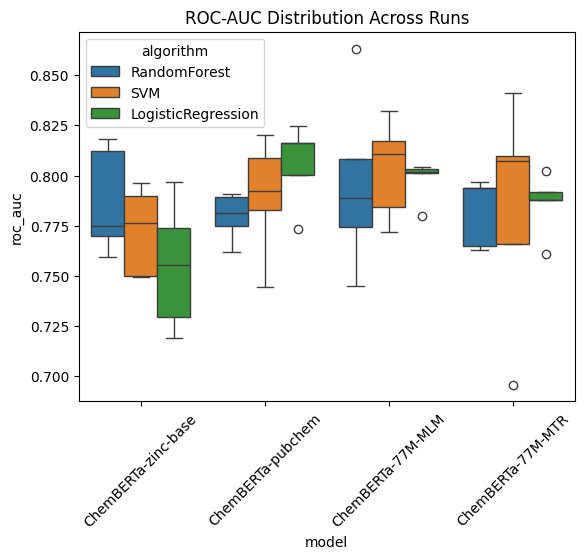


Comparing ChemBERTa-pubchem vs ChemBERTa-77M-MLM (SVM)
T-test p-value: 0.37522
Wilcoxon p-value: 0.43750


In [88]:
all_runs = run_repeated_benchmark(dataset, config)

df = flatten_results(all_runs)

summary = compute_confidence_intervals(df)
print(summary)

plot_boxplot(df)

compare_models(df, "ChemBERTa-pubchem", "ChemBERTa-77M-MLM")

In [84]:
from itertools import combinations
from scipy.stats import ttest_rel, wilcoxon
import pandas as pd

def compute_pairwise_tests(df, algorithm="SVM"):
    results = []

    models = df["model"].unique()

    for m1, m2 in combinations(models, 2):
        d1 = df[(df["model"] == m1) & (df["algorithm"] == algorithm)]["roc_auc"]
        d2 = df[(df["model"] == m2) & (df["algorithm"] == algorithm)]["roc_auc"]

        # Ensure aligned indices
        d1, d2 = d1.values, d2.values

        t_stat, t_p = ttest_rel(d1, d2)

        try:
            w_stat, w_p = wilcoxon(d1, d2)
        except:
            w_p = None

        results.append({
            "model_1": m1,
            "model_2": m2,
            "t_p_value": t_p,
            "wilcoxon_p_value": w_p
        })

    return pd.DataFrame(results)

In [78]:
def holm_bonferroni(df, p_col="t_p_value", alpha=0.05):
    df = df.copy()
    df = df.sort_values(p_col).reset_index(drop=True)

    m = len(df)
    df["rank"] = range(1, m+1)
    df["adjusted_alpha"] = alpha / (m - df["rank"] + 1)
    df["reject_null"] = df[p_col] < df["adjusted_alpha"]

    return df

In [79]:
def run_full_statistical_analysis(df, algorithm="SVM"):
    print(f"\n Running statistical tests for {algorithm}...\n")

    pairwise_df = compute_pairwise_tests(df, algorithm)

    corrected_df = holm_bonferroni(pairwise_df, p_col="t_p_value")

    print("\n Pairwise comparisons with Holm-Bonferroni correction:\n")
    print(corrected_df)

    return corrected_df

In [80]:
def run_full_statistical_analysis(df, algorithm="SVM"):
    print(f"\n Running statistical tests for {algorithm}...\n")

    pairwise_df = compute_pairwise_tests(df, algorithm)

    corrected_df = holm_bonferroni(pairwise_df, p_col="t_p_value")

    print("\n Pairwise comparisons with Holm-Bonferroni correction:\n")
    print(corrected_df)

    return corrected_df

In [86]:

def interpret_results(df):
    print("\n Interpretation:\n")

    for _, row in df.iterrows():
        m1 = row["model_1"]
        m2 = row["model_2"]
        p = row["t_p_value"]
        sig = row["reject_null"]

        if sig:
            print(f" {m1} vs {m2}: SIGNIFICANT difference (p={p:.4f})")
        else:
            print(f" {m1} vs {m2}: Not significant (p={p:.4f})")

In [89]:
stats_df = run_full_statistical_analysis(df, algorithm="SVM")
interpret_results(stats_df)


 Running statistical tests for SVM...


 Pairwise comparisons with Holm-Bonferroni correction:

               model_1            model_2  t_p_value  wilcoxon_p_value  rank   
0  ChemBERTa-zinc-base  ChemBERTa-77M-MLM   0.049429            0.1250     1  \
1    ChemBERTa-pubchem  ChemBERTa-77M-MLM   0.375222            0.4375     2   
2  ChemBERTa-zinc-base  ChemBERTa-pubchem   0.387949            0.4375     3   
3    ChemBERTa-77M-MLM  ChemBERTa-77M-MTR   0.564916            0.8125     4   
4  ChemBERTa-zinc-base  ChemBERTa-77M-MTR   0.598822            0.6250     5   
5    ChemBERTa-pubchem  ChemBERTa-77M-MTR   0.860893            0.6250     6   

   adjusted_alpha  reject_null  
0        0.008333        False  
1        0.010000        False  
2        0.012500        False  
3        0.016667        False  
4        0.025000        False  
5        0.050000        False  

 Interpretation:

 ChemBERTa-zinc-base vs ChemBERTa-77M-MLM: Not significant (p=0.0494)
 ChemBERTa-pubchem vs 